In [1]:
import sys
sys.path.append('..')
from osp import *

In [2]:
df_meta = get_corpus_metadata()

In [3]:
def get_df_probs(df_preds):
    l = []
    for i,r in df_preds.iterrows():
        x1,x2 = r['comparison'].split(' vs ')
        prob1 = r['prob_'+x1]
        prob2 = r['prob_'+x2]
        l.append(
            {
                'comparison':r['comparison'], 
                'id':r['id'], 
                'prob1':prob1, 
                'prob2':prob2, 
                'pred':x1 if prob1>prob2 else x2,
            }
        )
    return pd.DataFrame(l)


In [4]:
df_preds = pd.read_pickle('../data/raw/df_preds3.pkl.gz')
odfx = df_preds.query('predict_type!="cv"').reset_index().groupby(['comparison','id']).mean(numeric_only=True).reset_index()
df_probs = get_df_probs(odfx)

In [5]:
# df_probs = pd.read_pickle('../data/raw/df_probs3.pkl.gz')
id2disc = dict(zip(df_meta.index, df_meta['discipline']))
id2dec = dict(zip(df_meta.index, df_meta['decade']))
id2year = dict(zip(df_meta.index, df_meta['year']))
id2period = dict(zip(df_meta.index, df_meta['period']))
id2journal = dict(zip(df_meta.index, df_meta['journal']))
df_probs['true'] = df_probs['id'].apply(lambda x: id2disc[x.split('__')[0]])
df_probs['discipline'] = df_probs['id'].apply(lambda x: id2disc[x.split('__')[0]])
df_probs['period'] = df_probs['id'].apply(lambda x: id2period[x.split('__')[0]])
df_probs['pred'] = df_probs['pred'].apply(lambda x: x.split()[-1])
df_probs['journal'] = df_probs['id'].apply(lambda x: id2journal[x.split('__')[0]])
df_probs['irrelev'] = [x not in y for x,y in zip(df_probs['true'], df_probs['comparison'])]
df_probs['same_group'] = [x.split()[1] == x.split()[-1] for x in df_probs['comparison']]
df_probs['same_period'] = [x.split()[0] == x.split()[-2] for x in df_probs['comparison']]
df_probs['correct'] = df_probs['pred'] == df_probs['true']
df_probs['redundant'] = [x.split(' vs ')[0] > x.split(' vs ')[1] for x in df_probs['comparison']]
df_probs['decade'] = df_probs['id'].apply(lambda x: id2dec[x.split('__')[0]])
df_probs['year'] = df_probs['id'].apply(lambda x: id2year[x.split('__')[0]])
df_probs['predict_type'] = 'unseen'
df_probs['period_model'] = df_probs['comparison'].apply(lambda x: x.split()[0])
# df_probs = df_probs[df_probs.period_model>="1925"]
# df_probs = df_probs[~df_probs.irrelev]
df_probs = df_probs[~df_probs.same_group]
df_probs = df_probs[df_probs.same_period]
# df_probs = df_probs[~df_probs.redundant]
df_probs = df_probs[df_probs.comparison.str.contains('Philosophy')]
df_probs = df_probs[df_probs.discipline=="Philosophy"]
# df_probs = df_probs[df_probs.comparison.str.contains('Other')]
df_probs.columns

Index(['comparison', 'id', 'prob1', 'prob2', 'pred', 'true', 'discipline',
       'period', 'journal', 'irrelev', 'same_group', 'same_period', 'correct',
       'redundant', 'decade', 'year', 'predict_type', 'period_model'],
      dtype='object')

In [6]:
# df_probs[df_probs.discipline=="Other"]

In [7]:
figdf = get_avgs_df(df_probs,['year','predict_type','journal','period_model'],y='prob1').reset_index()
# figdf['discipline'] = pd.Categorical(figdf['discipline'], categories=['Philosophy','Other','Literature'])
figdf['mean']*=100

In [8]:
avgdf2 = get_avgs_df(df_probs,['journal'],y='prob1').reset_index().sort_values('mean', ascending=False)
# avgdf2 = avgdf2[avgdf2.period_model == avgdf2.period]
# avgdf2 = avgdf2[avgdf2.discipline=="Philosophy"]
avgdf2

,journal,mean,stderr,count
0,Proceedings of the Aristotelian Society,0.865270,0.001607,14920
1,Canadian Journal of Philosophy,0.863365,0.001769,11960
2,Philosophy and Phenomenological Research,0.850612,0.001370,25460
3,Dialectica,0.839855,0.002675,7170
4,The Journal of Philosophy,0.829834,0.001479,24000
5,Erkenntnis,0.817263,0.002057,14850
6,The Philosophical Review,0.803853,0.001812,20540
7,Synthese,0.771885,0.001177,58260
8,The Review of Metaphysics,0.763204,0.002167,14950
9,Ethics,0.754134,0.001740,26770


In [9]:
JRNLS = [
    # 'Proceedings of the Aristotelian Society',
    'The Philosophical Review',
    'The Journal of Philosophy',
    'The Review of Metaphysics',
    'Research in Phenomenology',
]

figdf['journal'] = pd.Categorical(figdf['journal'], categories=[j for j in avgdf2['journal'] if j in JRNLS])

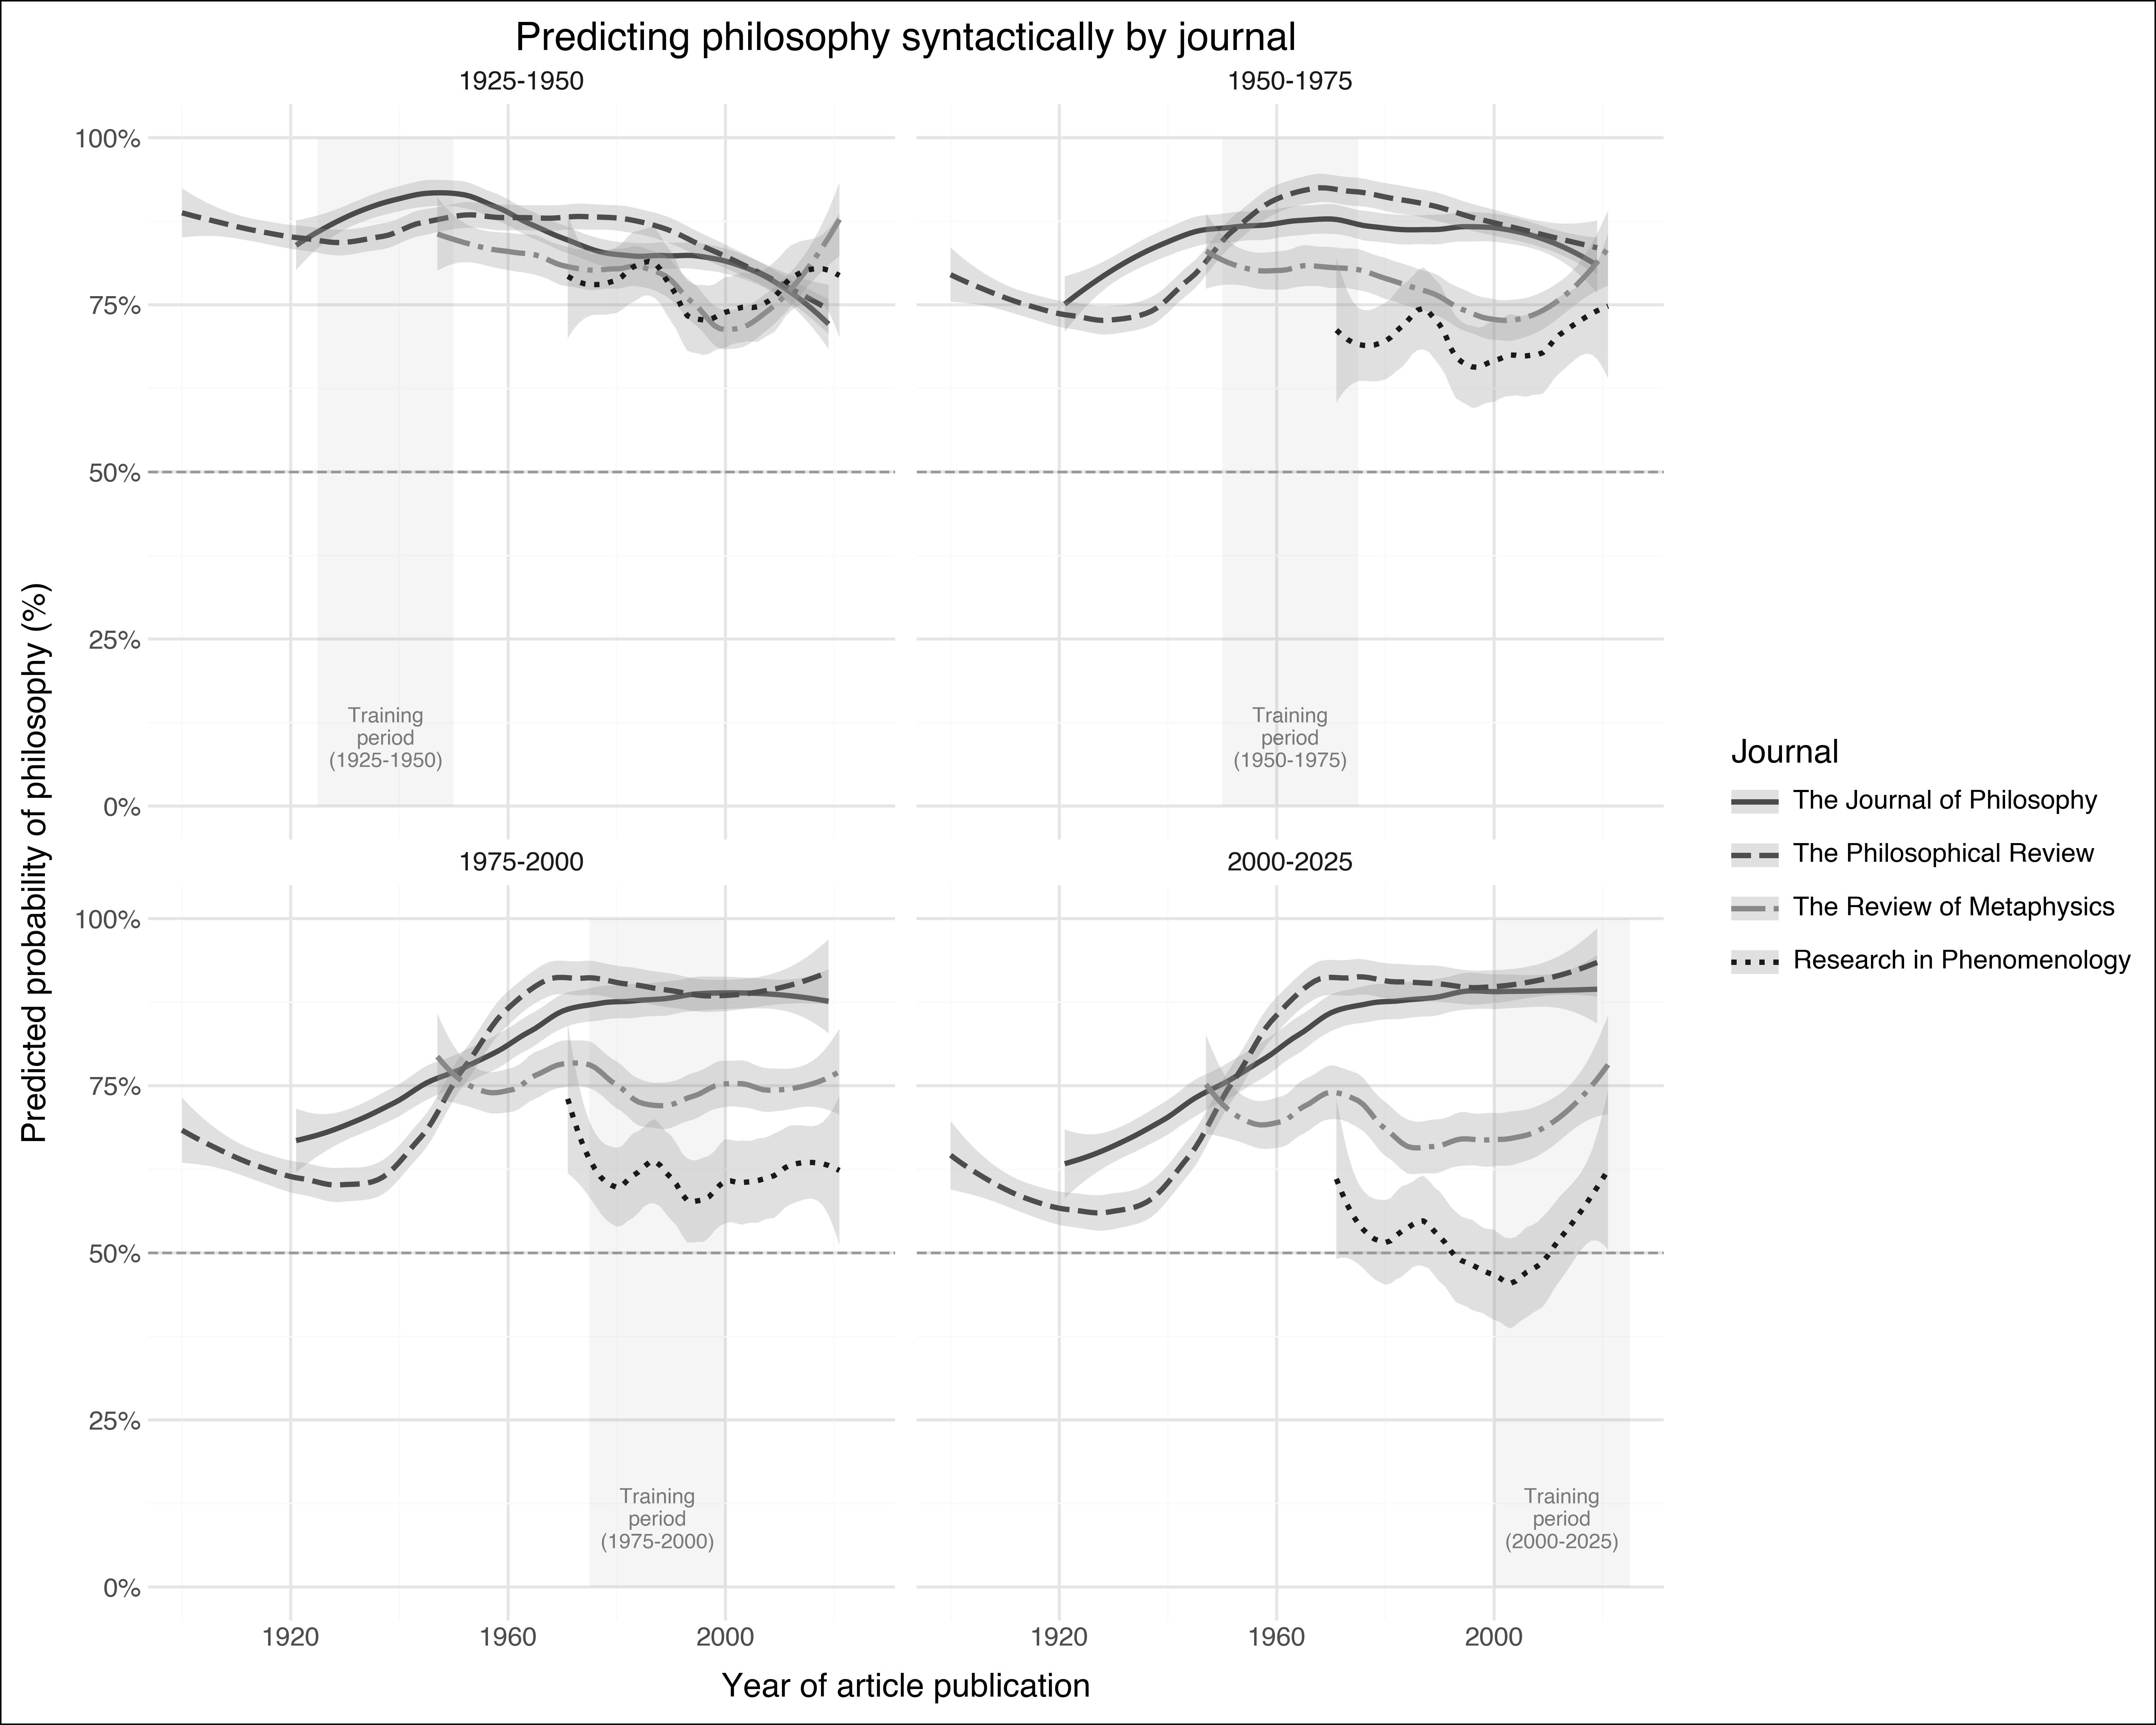

In [10]:
def plot_preds(figdf, facet_col='comparison', **labs):
    band_defs = pd.DataFrame([
        dict(period_model='1925-1950', xmin=1925, xmax=1950, label='Training\nperiod\n(1925-1950)'),
        dict(period_model='1950-1975', xmin=1950, xmax=1975, label='Training\nperiod\n(1950-1975)'),
        dict(period_model='1975-2000', xmin=1975, xmax=2000, label='Training\nperiod\n(1975-2000)'),
        dict(period_model='2000-2025', xmin=2000, xmax=2025, label='Training\nperiod\n(2000-2025)'),
    ])
    band_defs['ymin'] = 0
    band_defs['ymax'] = 100

    fig = (
        p9.ggplot(
            figdf,
            p9.aes(x='year', y='mean', color='journal'),
        )
        + p9.geom_hline(yintercept=50, color='gray', linetype='dashed',size=.5,alpha=0.75)
        + p9.geom_rect(
            p9.aes(xmin='xmin', xmax='xmax', ymin='ymin', ymax='ymax'),
            data=band_defs,
            inherit_aes=False,
            fill='gray',
            alpha=0.075,
        )
        + p9.geom_text(
            p9.aes(x='xmin + (xmax-xmin)/2', y=10, label='label'),
            data=band_defs,
            inherit_aes=False,
            alpha=.5,
            # ha='left',
            size=7,
        )
        # + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=1, alpha=0.75)
        # + p9.geom_point(p9.aes(y='mean',size='count',shape='journal'), alpha=0.5)
        + p9.facet_wrap(facet_col)
        + p9.theme_minimal()
        + p9.scale_size_continuous(range=(.25, 1.5))
        + p9.scale_y_continuous(labels=lambda l: [f'{int(v)}%' for v in l])
        + p9.geom_smooth(p9.aes(linetype='journal'), method='loess', span=0.5, alpha=0.3, size=1)
        + p9.scale_color_manual(
            values={
                'Research in Phenomenology': '#1a1a1a',   # near black
                'The Philosophical Review':   '#4d4d4d',   # dark gray
                'The Review of Metaphysics':  '#888888',   # medium gray
                'The Journal of Philosophy':  '#4a4a4a',   # mid-light gray
            }
        )
        # + p9.scale_color_gray()
        + p9.labs(**labs)
        + p9.theme(
            plot_background=p9.element_rect(fill='white'),
            # plot_title=p9.element_text(ha='left',size=13),
            plot_subtitle=p9.element_text(ha='left',size=11),
        )
    )
    return fig


fig = plot_preds(
    figdf.query('period_model>="1925" & journal in @JRNLS'), 
    facet_col='period_model', 
    title='Predicting philosophy syntactically by journal', 
    y="Predicted probability of philosophy (%)",
    x="Year of article publication",
    # subtitle="Predicting philosophy by quarter-century models",
    size='Number of samples',
    shape='Journal',
    color='Journal',
    linetype='Journal'
)
fig.save('../figures/preds_by_period_journal2.png')
fig

In [ ]:
figdf = get_avgs_df(df_probs, ['decade', 'true', 'comparison'], 'correct').reset_index().query('count>100')
figdf

In [ ]:
fig = (
    p9.ggplot(
        figdf,
        p9.aes(x='decade', y='mean',color='true')
    )
    + p9.geom_line()
    + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=0.2)
    + p9.facet_wrap('~comparison', ncol=4)
    + p9.theme_minimal()
    + p9.theme(figure_size=(15, 12))
    + p9.scale_y_continuous(limits=(.5,1))
)
fig